#### Librerias

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from scipy import sparse
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Mounted at /content/drive


#### Variables

In [2]:
MODELOS_PATH = "/content/drive/MyDrive/Trabajo práctico 3/modelos"

#### Carga de matrices y labels

In [3]:
X_train_bow = sparse.load_npz(f"{MODELOS_PATH}/X_train_bow.npz")
X_test_bow = sparse.load_npz(f"{MODELOS_PATH}/X_test_bow.npz")
X_train_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_train_tfidf.npz")
X_test_tfidf = sparse.load_npz(f"{MODELOS_PATH}/X_test_tfidf.npz")

y_train = np.load(f"{MODELOS_PATH}/y_train.npy")
y_test = np.load(f"{MODELOS_PATH}/y_test.npy")

X_train_bow.shape, X_test_bow.shape, X_train_tfidf.shape, X_test_tfidf.shape

((1600000, 20000), (498, 20000), (1600000, 20000), (498, 20000))

#### Test binario para evaluación

El train solo tiene clases 0 y 4, asi que filtro el test para evaluar
solo contra esas mismas clases. Los neutrales (2) se analizan en 06_evaluacion_final.

In [4]:
mask_binario = y_test != 2

X_test_bow_bin = X_test_bow[mask_binario]
X_test_tfidf_bin = X_test_tfidf[mask_binario]
y_test_bin = y_test[mask_binario]

y_test_bin.shape

(359,)

Quedan 359 tweets para evaluar (177 negativos + 182 positivos). Los 139 neutrales
del test se excluyen de la evaluación de estos modelos porque estructuralmente no
pueden predecir una clase que no existe en su entrenamiento — compararlos contra
neutrales sería medirles algo que no tienen forma de hacer.

#### Modelo 1 — Naive Bayes con Bag of Words

In [5]:
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_bow, y_train)

pred_nb = modelo_nb.predict(X_test_bow_bin)
print(classification_report(y_test_bin, pred_nb, target_names=["Negativo", "Positivo"]))

              precision    recall  f1-score   support

    Negativo       0.82      0.82      0.82       177
    Positivo       0.83      0.83      0.83       182

    accuracy                           0.83       359
   macro avg       0.83      0.83      0.83       359
weighted avg       0.83      0.83      0.83       359



Naive Bayes arranca con accuracy de 0.83, con precision y recall parejos entre las
dos clases (~0.82-0.83) — coherente con un training perfectamente balanceado. Para
un modelo sin ningún ajuste de hiperparámetros, es un punto de partida sólido: la
literatura sobre este mismo dataset reporta 0.80-0.85 para modelos clásicos.

#### Modelo 2 — Logistic Regression con TF-IDF

In [6]:
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train_tfidf, y_train)

pred_lr = modelo_lr.predict(X_test_tfidf_bin)
print(classification_report(y_test_bin, pred_lr, target_names=["Negativo", "Positivo"]))

              precision    recall  f1-score   support

    Negativo       0.82      0.80      0.81       177
    Positivo       0.81      0.83      0.82       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



Logistic Regression da 0.82, apenas por debajo de Naive Bayes. Es un resultado
llamativo: en teoría TF-IDF suele rendir mejor que un conteo simple, pero acá pasa
al revés. La hipótesis es que con tweets tan cortos (mediana de 69 caracteres, visto
en el EDA), la ponderación de TF-IDF tiene poco margen para diferenciarse de contar
palabras — hay muy pocas palabras por documento para "pesar" distinto.

#### Evaluación sobre train

In [7]:
pred_nb_train = modelo_nb.predict(X_train_bow)
pred_lr_train = modelo_lr.predict(X_train_tfidf)

print("=== NAIVE BAYES — TRAIN ===")
print(classification_report(y_train, pred_nb_train, target_names=["Negativo", "Positivo"]))

print("\n=== LOGISTIC REGRESSION — TRAIN ===")
print(classification_report(y_train, pred_lr_train, target_names=["Negativo", "Positivo"]))

=== NAIVE BAYES — TRAIN ===
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.78    800000
    Positivo       0.78      0.77      0.77    800000

    accuracy                           0.77   1600000
   macro avg       0.77      0.77      0.77   1600000
weighted avg       0.77      0.77      0.77   1600000


=== LOGISTIC REGRESSION — TRAIN ===
              precision    recall  f1-score   support

    Negativo       0.80      0.77      0.78    800000
    Positivo       0.78      0.81      0.79    800000

    accuracy                           0.79   1600000
   macro avg       0.79      0.79      0.79   1600000
weighted avg       0.79      0.79      0.79   1600000



El accuracy en train da MENOR que en test para los dos modelos — no hay overfitting.
Este resultado, que a primera vista parece raro, se analiza en profundidad en la
notebook 04 (la explicación está en el origen ruidoso de las etiquetas del training,
asignadas automáticamente por emoticono).

#### Matrices de confusión

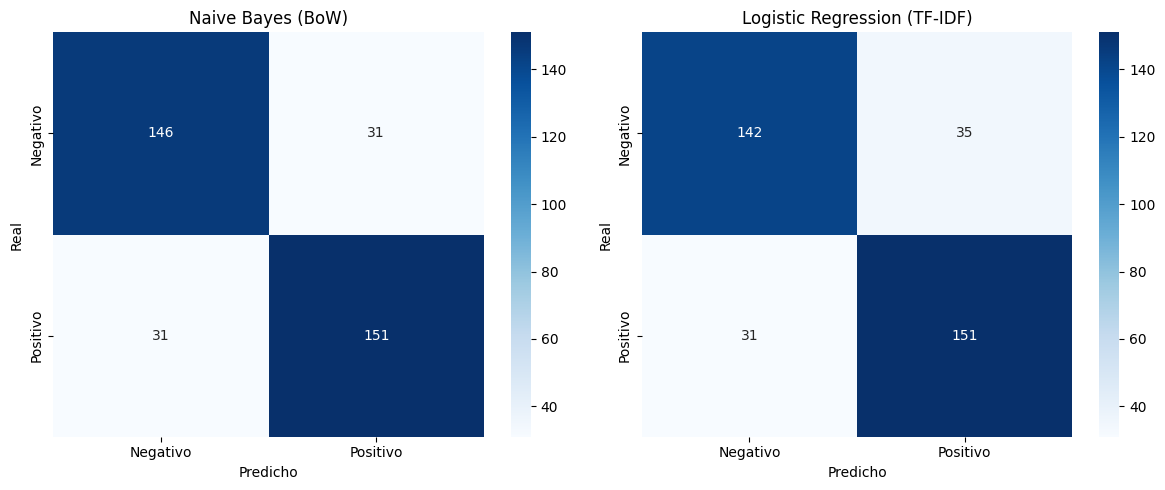

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test_bin, pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
axes[0].set_title("Naive Bayes (BoW)")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

cm_lr = confusion_matrix(y_test_bin, pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
axes[1].set_title("Logistic Regression (TF-IDF)")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

Naive Bayes reparte sus errores de forma perfectamente simétrica (31 falsos
positivos y 31 falsos negativos). Logistic Regression ya insinúa un sesgo: comete
más falsos positivos (35) que falsos negativos (31), es decir, tiende a ser más
"generoso" clasificando como positivo. Este patrón se confirma más adelante con
los modelos optimizados y las matrices completas de train.

#### Guardado de modelos baseline

In [9]:
joblib.dump(modelo_nb, f"{MODELOS_PATH}/modelo_nb_baseline.pkl")
joblib.dump(modelo_lr, f"{MODELOS_PATH}/modelo_lr_baseline.pkl")

['/content/drive/MyDrive/Trabajo práctico 3/modelos/modelo_lr_baseline.pkl']